Χρήση της συσκευής: cuda


100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


car | deer | plane | car
Epoch [1/40] | Train Acc: 28.15% | Test Acc: 36.84% | Loss: 1.9693
Epoch [2/40] | Train Acc: 38.80% | Test Acc: 40.96% | Loss: 1.7071
Epoch [3/40] | Train Acc: 42.34% | Test Acc: 43.92% | Loss: 1.6127
Epoch [4/40] | Train Acc: 44.74% | Test Acc: 45.64% | Loss: 1.5480
Epoch [5/40] | Train Acc: 46.18% | Test Acc: 47.46% | Loss: 1.5032
Epoch [6/40] | Train Acc: 47.49% | Test Acc: 48.07% | Loss: 1.4721
Epoch [7/40] | Train Acc: 48.59% | Test Acc: 48.33% | Loss: 1.4425
Epoch [8/40] | Train Acc: 49.05% | Test Acc: 49.58% | Loss: 1.4255
Epoch [9/40] | Train Acc: 49.88% | Test Acc: 49.98% | Loss: 1.4029
Epoch [10/40] | Train Acc: 50.58% | Test Acc: 50.81% | Loss: 1.3829
Epoch [11/40] | Train Acc: 51.09% | Test Acc: 50.50% | Loss: 1.3671
Epoch [12/40] | Train Acc: 51.50% | Test Acc: 50.83% | Loss: 1.3519
Epoch [13/40] | Train Acc: 52.13% | Test Acc: 51.91% | Loss: 1.3373
Epoch [14/40] | Train Acc: 52.55% | Test Acc: 52.55% | Loss: 1.3274
Epoch [15/40] | Train Acc: 52.92

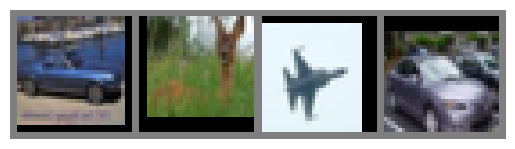

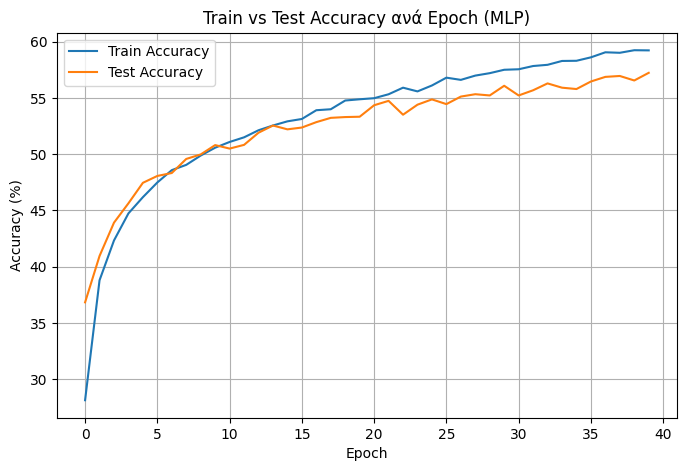

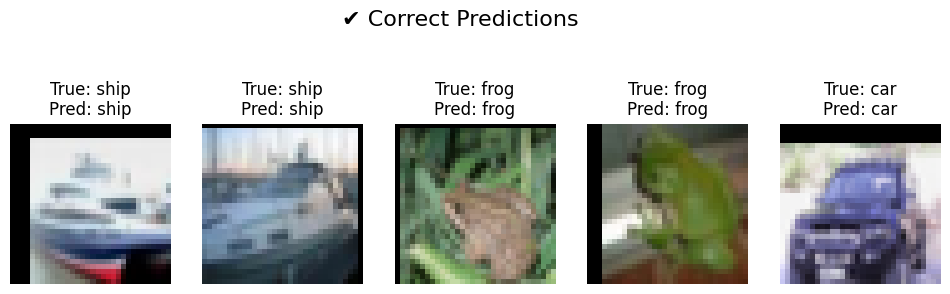

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


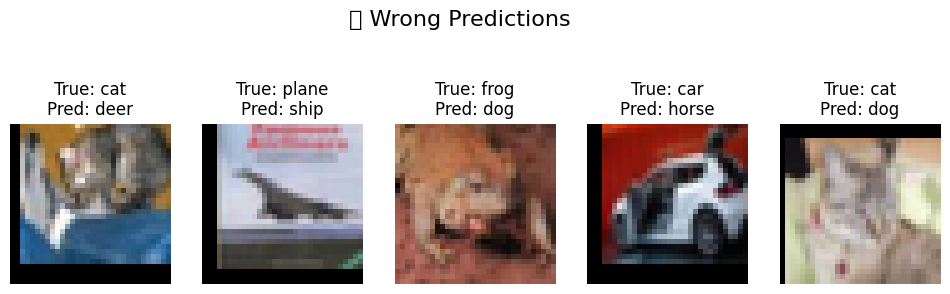

In [ ]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import time


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Χρήση της συσκευής:", device)


#---- DATA AUGMENTATION ----
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                        (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                        (0.5, 0.5, 0.5))
])


# CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=train_transform)

#DataLoaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']




def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

dataiter = iter(trainloader)
images, labels = next(dataiter)


img_grid = torchvision.utils.make_grid(images[:4])
matplotlib_imshow(img_grid)

print(' | '.join(classes[labels[j]] for j in range(4)))


#Ορισμός MLP αρχιτεκτονικής
# Δύο κρυφά επίπεδα: 512 και 256 νευρώνες.
# ReLU για μη γραμμικότητα.
# Dropout 0.5

class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.fc1 = nn.Linear(32*32*3,512) #input layer -> hidden layer
    self.fc2 = nn.Linear(512,256)
    self.fc3 = nn.Linear(256,10) #hidden layer -> output

    self.dropout = nn.Dropout(0.5)
    self.activation = nn.ReLU() #ReLU activation

  def forward(self, x):
    x=x.view(-1,32*32*3) #flatten (batch_size, 3072)
    x = self.dropout(self.activation(self.fc1(x)))
    x = self.dropout(self.activation(self.fc2(x)))
    x=self.fc3(x)
    return x

model=MLP().to(device)

# Adam optimizer με learning rate 1e-4
#weight_decay=1e-4

loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-4)

train_losses=[]
train_accuracies=[]
test_accuracies=[]
start_time=time.time()


EPOCHS=40
for epoch in range(EPOCHS):
  running_loss=0.0
  correct, total= 0,0

  for images, labels in trainloader:
    images, labels= images.to(device), labels.to(device)

    #forward pass
    outputs= model(images)
    loss=loss_fn(outputs, labels)

    optimizer.zero_grad() #μηδενισμός gradients
    loss.backward() #backward pass
    optimizer.step() #update weights

    running_loss+=loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_acc = 100 * correct / total
  train_losses.append(running_loss / len(trainloader))
  train_accuracies.append(train_acc)


  model.eval()
  correct, total = 0, 0

  with torch.no_grad():
      for images, labels in testloader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  test_acc = 100 * correct / total
  test_accuracies.append(test_acc)
  print(f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Acc: {train_acc:.2f}% "
        f"| Test Acc: {test_acc:.2f}% "
        f"| Loss: {running_loss/len(trainloader):.4f}")




end_time = time.time()
elapsed_time = end_time - start_time

print("\nΕκπαίδευση ολοκληρώθηκε!")
print(f"Χρόνος εκπαίδευσης: {elapsed_time:.2f} δευτερόλεπτα\n")

#Γράφημα Επίδοσης

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy ανά Epoch (MLP)")
plt.grid(True)
plt.legend()
plt.show()

#Εμφάνιση σωστών/ λάθος προβλέψεων

def show_predictions(model, dataloader, classes, device, num_correct=5, num_wrong=5):

    model.eval()
    correct_imgs = []
    wrong_imgs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for img, label, pred in zip(images, labels, preds):
                if len(correct_imgs) < num_correct and pred == label:
                    correct_imgs.append((img.cpu(), label.cpu(), pred.cpu()))
                elif len(wrong_imgs) < num_wrong and pred != label:
                    wrong_imgs.append((img.cpu(), label.cpu(), pred.cpu()))

                if len(correct_imgs) == num_correct and len(wrong_imgs) == num_wrong:
                    break
            if len(correct_imgs) == num_correct and len(wrong_imgs) == num_wrong:
                break

    # ---- PLOT ----
    def plot_samples(samples, title):
        plt.figure(figsize=(12, 4))
        plt.suptitle(title, fontsize=16)
        for i, (img, label, pred) in enumerate(samples):
            img = img / 2 + 0.5  # denormalize
            np_img = img.numpy().transpose(1, 2, 0)
            plt.subplot(1, len(samples), i+1)
            plt.imshow(np_img)
            plt.axis("off")
            plt.title(f"True: {classes[label]}\nPred: {classes[pred]}")
        plt.show()

    plot_samples(correct_imgs, "✔ Correct Predictions")
    plot_samples(wrong_imgs, "❌ Wrong Predictions")



show_predictions(model, testloader, classes, device)

